In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("/Users/abinkgeo/BridgeLabz/review/review/13-01-2025/amazon_products_sales_data_cleaned.csv")

df.head()


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [3]:
df.info()

df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


In [4]:
df.isnull().sum()

product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

In [5]:
df.groupby("is_sponsored")["purchased_last_month"].mean()


is_sponsored
Organic       487.876825
Sponsored    7681.154593
Name: purchased_last_month, dtype: float64

In [6]:
price_bins=pd.cut(df["discounted_price"],bins=5)
df.groupby(price_bins,observed=True)["purchased_last_month"].mean()

discounted_price
(-3.287, 1091.528]      1368.544719
(1091.528, 2180.896]      81.456044
(2180.896, 3270.264]     101.351351
(3270.264, 4359.632]      70.000000
(4359.632, 5449.0]              NaN
Name: purchased_last_month, dtype: float64

In [53]:
# Coupon effect
df.groupby("has_coupon")["purchased_last_month"].mean().sort_values(ascending=False)


has_coupon
Save $0.33  with coupon                      20000.000000
Save 6%  with coupon                          8000.000000
Save $2.00  with coupon                       6833.333333
Save $4.00  with coupon                       6333.333333
Save 7%  with coupon                          6000.000000
Save $1.00  with coupon                       2625.000000
Save $1.50  with coupon                       2500.000000
Save $8.00  with coupon                       1750.000000
Save $18.00  with coupon                      1687.500000
No Coupon                                     1313.057694
Save 15%  with coupon                         1027.638191
Save 8%  with coupon                          1000.000000
Save 5%  with coupon                           915.263158
Save 25%  with coupon                          833.333333
Save $5.00  with coupon                        750.000000
Save $40.00  with coupon                       600.000000
Save 20%  with coupon                          550.000000
Sav

In [8]:
df.groupby("product_category")["purchased_last_month"].mean()

product_category
Cameras                 321.392843
Chargers & Cables       531.791721
Gaming                  185.435435
Headphones              231.168177
Laptops                 514.990956
Networking              327.482270
Other Electronics       631.483871
Phones                  642.361350
Power & Batteries      9396.855911
Printers & Scanners     331.335616
Smart Home              350.988142
Speakers                234.358707
Storage                 515.292276
TV & Display            521.303714
Wearables              1757.158837
Name: purchased_last_month, dtype: float64

In [9]:
discount=pd.cut(df["discount_percentage"],bins=[0,10,20,30,40,50,60,70,80,90,100])
df.groupby(discount,observed=True)["purchased_last_month"].mean()



discount_percentage
(0, 10]      402.497770
(10, 20]    4534.449186
(20, 30]     937.219028
(30, 40]     853.276081
(40, 50]    2355.489865
(50, 60]     481.167608
(60, 70]     937.500000
(70, 80]      59.895833
(80, 90]     275.000000
Name: purchased_last_month, dtype: float64

In [10]:
rating= pd.cut(df["product_rating"],bins=[0,2,3,4,5])
df.groupby(rating,observed=False)["purchased_last_month"].mean()


product_rating
(0, 2]      50.000000
(2, 3]     106.250000
(3, 4]     187.174542
(4, 5]    1468.893487
Name: purchased_last_month, dtype: float64

In [11]:
df[[
    "discounted_price",
    "discount_percentage",
    "product_rating",
    "total_reviews",
    "purchased_last_month"
]].corr()


,discounted_price,discount_percentage,product_rating,total_reviews,purchased_last_month
discounted_price,1.000000,-0.130729,-0.085647,-0.081533,-0.095635
discount_percentage,-0.130729,1.000000,0.016241,0.029542,0.043190
product_rating,-0.085647,0.016241,1.000000,0.099750,0.151883
total_reviews,-0.081533,0.029542,0.099750,1.000000,0.295952
purchased_last_month,-0.095635,0.043190,0.151883,0.295952,1.000000


In [ ]:
df[
    (df["product_rating"] >= 4) &
    (df["purchased_last_month"] < df["purchased_last_month"].median())
]


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,195.99,No Badge,Organic,No Coupon,NaN,2025-09-04,NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,https://www.amazon.com/Elgato-4K-Pro-Internal-...,2025-08-30 19:56:33,TV & Display,0.00
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,89.99,No Badge,Organic,Save $25.00 with coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,https://www.amazon.com/Arlo-Essential-Spotligh...,2025-08-30 19:56:33,Cameras,0.00
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,1099.99,Save 18%,Organic,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,https://www.amazon.com/GIGABYTE-FO32U2-32-3840...,2025-08-30 19:56:33,Chargers & Cables,18.18
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,No Badge,Organic,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,https://www.amazon.com/Monoprice-XLR-Male-4-In...,2025-08-30 19:56:33,Chargers & Cables,34.98


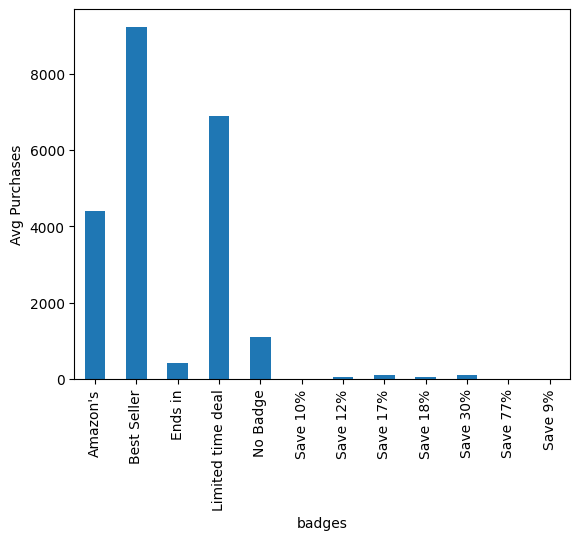

In [14]:
df.groupby("is_best_seller")["purchased_last_month"].mean().plot(kind="bar")
plt.xlabel("badges")
plt.ylabel("Avg Purchases")
plt.show()

In [67]:
df["sustainability_tags"].value_counts(normalize=True)*100


sustainability_tags
Small Business                    39.348592
Carbon impact                     22.564554
Works with Alexa                  12.470657
Energy efficiency                  7.687793
Alexa Built-in                     5.399061
Manufacturing practices            4.342723
Energy efficiency +3 more          3.550469
Energy efficiency +1 more          2.728873
Forestry practices                 0.528169
Safer chemicals +2 more            0.528169
Recycled materials                 0.205399
Recycled materials +2 more         0.205399
Safer chemicals +1 more            0.176056
Recycled materials +3 more         0.117371
Made in Italy                      0.117371
1 sustainability certification     0.029343
Name: proportion, dtype: float64

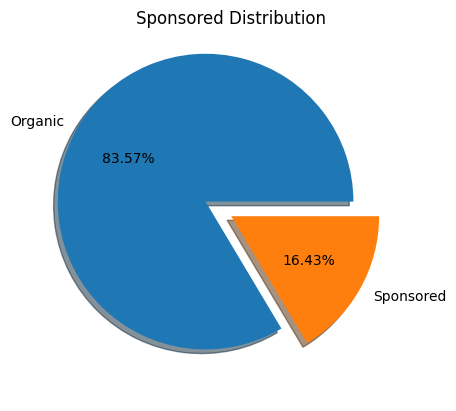

In [69]:
df["is_sponsored"].value_counts().plot(kind="pie", autopct="%1.2f%%",explode=(0.2,0),shadow=True)
plt.title("Sponsored Distribution")
plt.ylabel("")
plt.show()